# 🤖 Notebook 3 — Training, Evaluasi & Hyperparameter Tuning
Model: Random Forest + XGBoost (Ensemble Learning)
Target: `failure_flag` — Klasifikasi kegagalan lokasi pertanian.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score, f1_score)

# Load data hasil preprocessing
data = pd.read_csv('../dataset/data_cleaned.csv')
selected_features = joblib.load('../output/selected_features.pkl')

X = data[selected_features]
y = data['failure_flag']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribusi target:")
print(y.value_counts())


Shape X: (682695, 18)
Shape y: (682695,)

Distribusi target:
failure_flag
0    455130
1    227565
Name: count, dtype: int64


## 1. Split Data Train & Test

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")


Train: (546156, 18), Test: (136539, 18)
Train target distribution:
failure_flag
0    364104
1    182052
Name: count, dtype: int64

Test target distribution:
failure_flag
0    91026
1    45513
Name: count, dtype: int64


## 2. Baseline Model — Perbandingan Beberapa Model

In [3]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=== Cross-Validation (5-Fold) Baseline ===")
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    results[name] = scores
    print(f"{name:15s} | F1 Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

=== Cross-Validation (5-Fold) Baseline ===
Random Forest   | F1 Mean: 1.0000 | Std: 0.0000
XGBoost         | F1 Mean: 0.9999 | Std: 0.0000


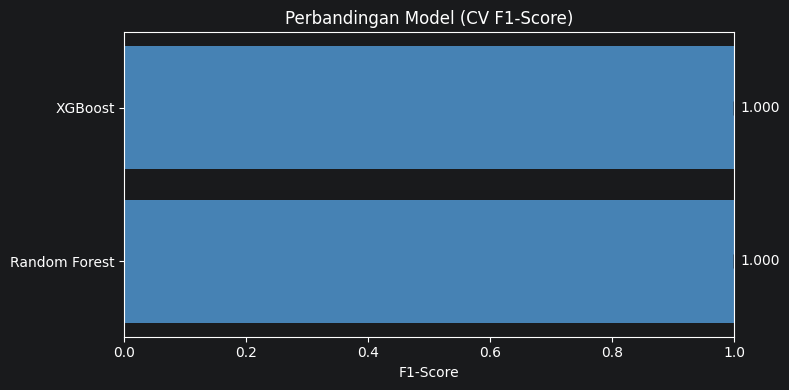

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
means = [r.mean() for r in results.values()]
stds = [r.std() for r in results.values()]
bars = ax.barh(names, means, xerr=stds, capsize=5, color='steelblue')
ax.set_title('Perbandingan Model (CV F1-Score)')
ax.set_xlabel('F1-Score')
ax.set_xlim(0, 1)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + 0.01, i, f'{m:.3f}', va='center')
plt.tight_layout()
plt.show()


## 3. Hyperparameter Tuning — Random Forest

In [5]:
# 1. Random Forest - Hyperparameter Tuning
# ================================
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

print("\n=== Random Forest ===")
print("Best params:", rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  45.4s
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  45.8s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  46.1s
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  46.7s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  45.9s
[CV] END max_depth=12, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  47.4s
[CV] END max_depth=12, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  47.0s
[CV] END max_depth=12, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=

## 4. Hyperparameter Tuning —> XGBoost


In [6]:
# 2. XGBoost - Hyperparameter Tuning
# ================================
param_dist_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_search.fit(X_train, y_train)

print("\n=== XGBoost ===")
print("Best params:", xgb_search.best_params_)
print(f"Best CV F1: {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=  18.0s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=  17.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=  18.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=  21.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=  20.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=  21.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=  21.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=  22.8s
[CV] END colsa

## 5. Ensemble — Voting Classifier

In [7]:
# 3. Ensemble (RF + XGB)
# ================================
ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb),
    ],
    voting='soft',
    n_jobs=-1
)

ensemble.fit(X_train, y_train)
print("\nEnsemble model berhasil dilatih.")


Ensemble model berhasil dilatih.


## 6. Evaluasi Final pada Data Test

In [8]:
# 4. Evaluasi Ensemble
# ================================
scores = cross_val_score(
    ensemble,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print(f"Ensemble CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

Ensemble CV F1: 1.0000 ± 0.0000


## 7. Confusion Matrix

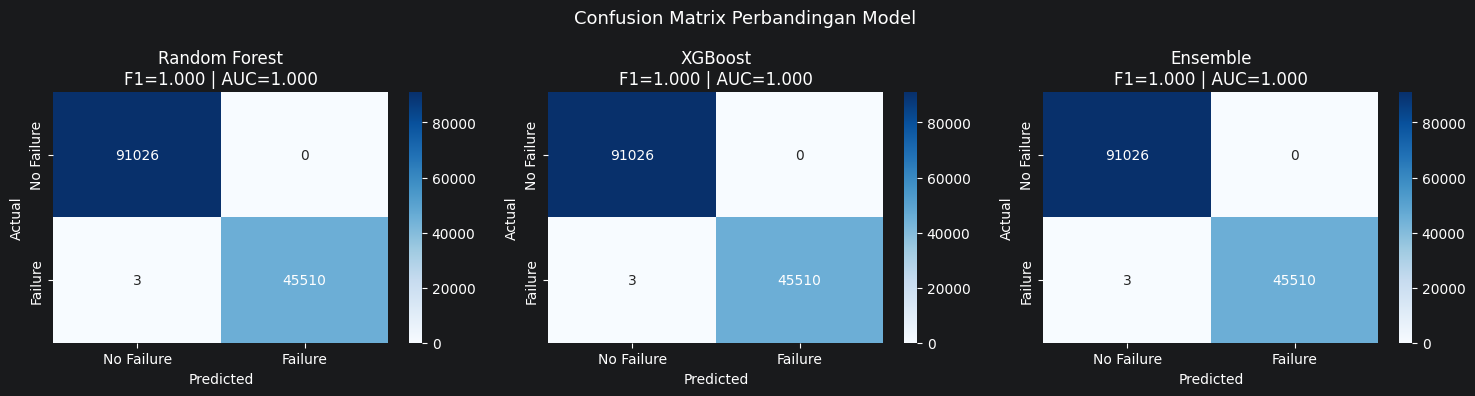

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

preds = {}

model_eval = {
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'Ensemble': ensemble,
}

for name, model in model_eval.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    preds[name] = (y_pred, y_prob, acc, f1, auc)
# jumlah model
n_models = len(preds)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

# kalau cuma 1 model, axes bukan array → amankan
if n_models == 1:
    axes = [axes]

for ax, (name, (y_pred, y_prob, acc, f1, auc)) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['No Failure', 'Failure'],
        yticklabels=['No Failure', 'Failure']
    )

    ax.set_title(f'{name}\nF1={f1:.3f} | AUC={auc:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Perbandingan Model', fontsize=13)
plt.tight_layout()
plt.show()

## 8. ROC Curve

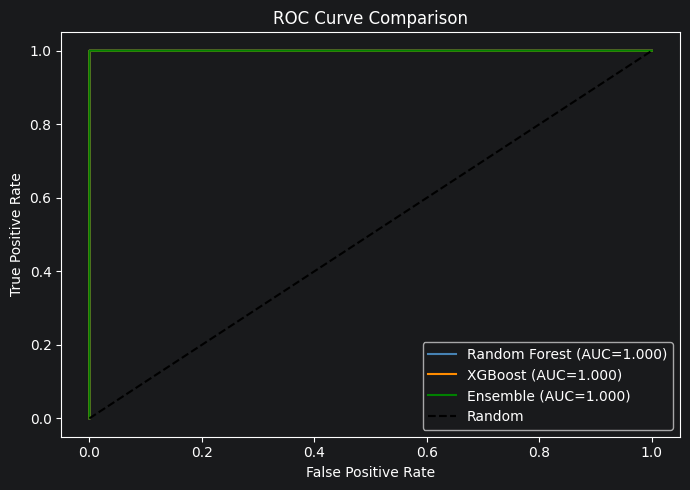

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))

# warna default (akan diulang kalau model lebih banyak)
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for i, (name, (y_pred, y_prob, acc, f1, auc)) in enumerate(preds.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    ax.plot(
        fpr,
        tpr,
        label=f'{name} (AUC={auc:.3f})',
        color=colors[i % len(colors)]
    )

# garis random baseline
ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## 9. Feature Importance (Random Forest)

=== Feature Importance (Top 15) ===
suitability_score           0.3065
stress_level                0.1975
ph_stress_flag              0.1615
soil_temp_c                 0.0819
soil_ph                     0.0623
moisture_regime             0.0536
thermal_regime              0.0448
air_temp_c                  0.0266
soil_moisture_pct           0.0202
moisture_limit_dry          0.0083
salinity_ec                 0.0077
moisture_limit_wet          0.0058
organic_matter_pct          0.0058
nutrient_balance            0.0057
cation_exchange_capacity    0.0036
dtype: float64


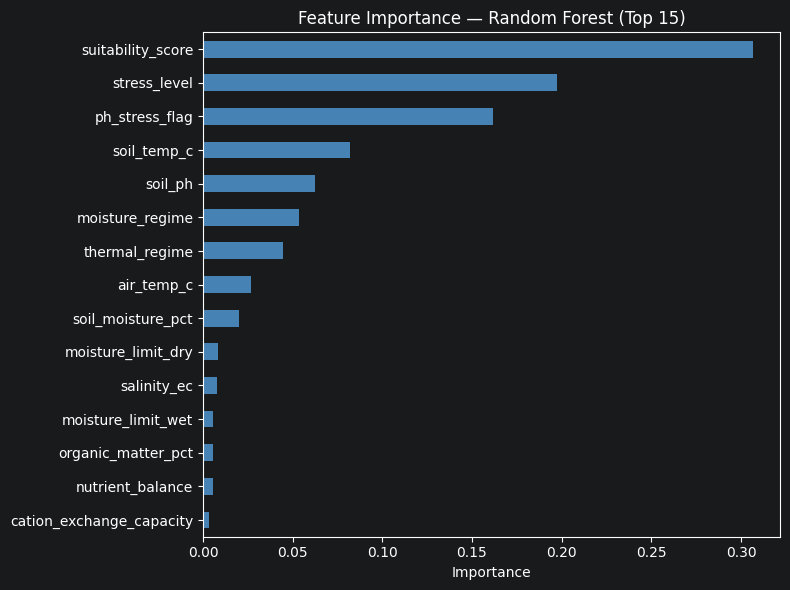

In [11]:
importances = pd.Series(best_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print("=== Feature Importance (Top 15) ===")
print(importances.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest (Top 15)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 10. Pilih Model Terbaik & Simpan

In [12]:
# Pilih model dengan F1-Score tertinggi
best_name = max(preds, key=lambda k: preds[k][3])
print(f"\nModel terbaik berdasarkan F1-Score: {best_name}")
print(f"  F1: {preds[best_name][3]:.4f}")
print(f"  AUC: {preds[best_name][4]:.4f}")

model_map = {
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'Ensemble': ensemble,
}

final_model = model_map[best_name]

# Simpan model
joblib.dump(final_model, '../model/model.pkl')
print(f"\n✅ Model disimpan ke: ../model/model.pkl")


Model terbaik berdasarkan F1-Score: Random Forest
  F1: 1.0000
  AUC: 1.0000

✅ Model disimpan ke: ../model/model.pkl


## 11. Verifikasi Model Tersimpan

In [13]:
loaded_model = joblib.load('../model/model.pkl')
y_pred_check = loaded_model.predict(X_test[:5])
print("=== Prediksi dari model yang dimuat ===")
print("Prediksi:", y_pred_check)
print("Aktual  :", y_test.values[:5])
print("\n✅ Model berhasil dimuat dan berfungsi dengan baik.")


=== Prediksi dari model yang dimuat ===
Prediksi: [0 0 1 1 0]
Aktual  : [0 0 1 1 0]

✅ Model berhasil dimuat dan berfungsi dengan baik.


## ✅ Ringkasan Training
- Model yang dibandingkan: Random Forest, XGBoost
- Hyperparameter tuning dengan `RandomizedSearchCV` + `StratifiedKFold` (5-fold CV)
- Ensemble `VotingClassifier` (soft voting) menggabungkan RF + GB + LR
- Model terbaik dipilih berdasarkan F1-Score pada test set
- Model final disimpan sebagai `output/model.pkl`
